# Notebook 04 — DistilBERT Fine-tuning
## AI-Powered Customer Feedback Intelligence System

**Purpose:** Fine-tune a pretrained DistilBERT model for binary sentiment classification.

**Pipeline:**
Raw Text → Tokenizer → input_ids + attention_mask → DistilBERT → Classification Head → Positive/Negative

**Key decisions:**
- Model     : distilbert-base-uncased
- Max length: 256 tokens (covers 95% of reviews)
- Batch size: 32 (fits in 4GB VRAM)
- Epochs    : 3
- Optimizer : AdamW
- LR        : 2e-5

**Hardware:** NVIDIA RTX 2050 (4GB VRAM) — CUDA enabled

In [1]:
# ============================================================
# IMPORTS
# ============================================================

import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    classification_report, confusion_matrix
)
import seaborn as sns
from tqdm import tqdm
import warnings
import time

warnings.filterwarnings('ignore')

# ── Device setup ────────────────────────────────────────────
# This automatically uses GPU if available, CPU otherwise.
# torch.device('cuda') tells PyTorch to use your RTX 2050.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"✅ Imports successful")
print(f"🖥️  Device : {device}")
if device.type == 'cuda':
    print(f"🎮 GPU    : {torch.cuda.get_device_name(0)}")
    print(f"💾 VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

✅ Imports successful
🖥️  Device : cuda
🎮 GPU    : NVIDIA GeForce RTX 2050
💾 VRAM   : 4.0 GB


In [2]:
# ============================================================
# CONFIGURATION
# All hyperparameters defined in one place.
# This is good engineering practice — never scatter magic
# numbers throughout the code.
# ============================================================

CONFIG = {
    # Model
    'model_name'  : 'distilbert-base-uncased',

    # distilbert-base-uncased means:
    #   - distilbert  : smaller/faster version of BERT
    #   - base        : standard size (not large)
    #   - uncased     : text is lowercased before tokenizing
    #                   "Great" and "great" are treated the same
    #                   This is fine for sentiment analysis

    # Data
    'max_length'  : 256,     # truncate/pad all reviews to 256 tokens
    'batch_size'  : 32,      # 32 reviews processed together per step
                             # 16 is safer for 4GB VRAM, 32 works if nothing else runs

    # Training
    'epochs'      : 3,       # 3 full passes through training data
                             # DistilBERT converges fast — more epochs = overfitting risk
    'learning_rate': 2e-5,   # very small — we don't want to destroy pretrained weights
                             # typical range for fine-tuning: 1e-5 to 5e-5
    'warmup_ratio': 0.1,     # first 10% of steps use increasing LR (warmup)
                             # prevents unstable updates at the start of training

    # Paths
    'processed_path' : os.path.join('..', 'data', 'processed'),
    'model_save_path': os.path.join('..', 'models', 'distilbert'),
    'assets_path'    : os.path.join('..', 'assets'),
}

os.makedirs(CONFIG['model_save_path'], exist_ok=True)
os.makedirs(CONFIG['assets_path'], exist_ok=True)

print("✅ Configuration set")
for key, val in CONFIG.items():
    print(f"   {key:<20} : {val}")

✅ Configuration set
   model_name           : distilbert-base-uncased
   max_length           : 256
   batch_size           : 32
   epochs               : 3
   learning_rate        : 2e-05
   warmup_ratio         : 0.1
   processed_path       : ..\data\processed
   model_save_path      : ..\models\distilbert
   assets_path          : ..\assets


In [3]:
# ============================================================
# LOAD DATA
# ============================================================

df_train = pd.read_csv(os.path.join(CONFIG['processed_path'], 'train.csv'))
df_val   = pd.read_csv(os.path.join(CONFIG['processed_path'], 'val.csv'))
df_test  = pd.read_csv(os.path.join(CONFIG['processed_path'], 'test.csv'))

# Fill any NaN in text with empty string
df_train['cleaned_text'] = df_train['cleaned_text'].fillna('')
df_val['cleaned_text']   = df_val['cleaned_text'].fillna('')
df_test['cleaned_text']  = df_test['cleaned_text'].fillna('')

print("✅ Data loaded")
print(f"   Train : {len(df_train):,}")
print(f"   Val   : {len(df_val):,}")
print(f"   Test  : {len(df_test):,}")
print(f"\n   Positive in train: {(df_train['sentiment']==1).sum():,}")
print(f"   Negative in train: {(df_train['sentiment']==0).sum():,}")

✅ Data loaded
   Train : 88,001
   Val   : 10,999
   Test  : 11,000

   Positive in train: 44,001
   Negative in train: 44,000


In [4]:
# ============================================================
# LOAD TOKENIZER + LIVE EXAMPLE
# ============================================================

print("Loading DistilBERT tokenizer...")
print("(First run downloads ~250MB from HuggingFace — subsequent runs use cache)\n")

tokenizer = DistilBertTokenizerFast.from_pretrained(CONFIG['model_name'])

print(f"✅ Tokenizer loaded")
print(f"   Vocabulary size: {tokenizer.vocab_size:,} tokens")

# ── Live tokenization example ───────────────────────────────
print("\n" + "=" * 60)
print("TOKENIZATION EXAMPLE")
print("=" * 60)

example_reviews = [
    "The product quality is excellent and I love it!",
    "This is terrible, it stopped working after two days."
]

for review in example_reviews:
    print(f"\nOriginal : {review}")
    tokens = tokenizer.tokenize(review)
    print(f"Tokens   : {tokens}")
    encoded = tokenizer.encode(review)
    print(f"Input IDs: {encoded}")
    print(f"Length   : {len(tokens)} tokens")

# ── Full encoding with padding/truncation ───────────────────
print("\n" + "=" * 60)
print("FULL ENCODING WITH ATTENTION MASK")
print("=" * 60)

encoded_batch = tokenizer(
    example_reviews,
    max_length=20,          # short for display purposes
    padding=True,           # pad shorter sequences
    truncation=True,        # truncate longer sequences
    return_tensors='pt'     # return PyTorch tensors
)

print(f"\ninput_ids shape     : {encoded_batch['input_ids'].shape}")
print(f"attention_mask shape: {encoded_batch['attention_mask'].shape}")
print(f"\ninput_ids:")
print(encoded_batch['input_ids'])
print(f"\nattention_mask (1=real token, 0=padding):")
print(encoded_batch['attention_mask'])
print("\n✅ Notice: shorter sequence gets padded with 0s")
print("   Attention mask marks padding as 0 so model ignores it")

Loading DistilBERT tokenizer...
(First run downloads ~250MB from HuggingFace — subsequent runs use cache)

✅ Tokenizer loaded
   Vocabulary size: 30,522 tokens

TOKENIZATION EXAMPLE

Original : The product quality is excellent and I love it!
Tokens   : ['the', 'product', 'quality', 'is', 'excellent', 'and', 'i', 'love', 'it', '!']
Input IDs: [101, 1996, 4031, 3737, 2003, 6581, 1998, 1045, 2293, 2009, 999, 102]
Length   : 10 tokens

Original : This is terrible, it stopped working after two days.
Tokens   : ['this', 'is', 'terrible', ',', 'it', 'stopped', 'working', 'after', 'two', 'days', '.']
Input IDs: [101, 2023, 2003, 6659, 1010, 2009, 3030, 2551, 2044, 2048, 2420, 1012, 102]
Length   : 11 tokens

FULL ENCODING WITH ATTENTION MASK

input_ids shape     : torch.Size([2, 13])
attention_mask shape: torch.Size([2, 13])

input_ids:
tensor([[ 101, 1996, 4031, 3737, 2003, 6581, 1998, 1045, 2293, 2009,  999,  102,
            0],
        [ 101, 2023, 2003, 6659, 1010, 2009, 3030, 2551, 2044,

In [5]:
# ============================================================
# PYTORCH DATASET CLASS
# ============================================================

# WHY WE NEED A DATASET CLASS:
# PyTorch's DataLoader needs a standardized way to access
# individual samples. We create a custom Dataset class that:
# 1. Stores our reviews and labels
# 2. Tokenizes each review on demand
# 3. Returns tensors that PyTorch can process
#
# The DataLoader then batches these automatically.

class AmazonReviewDataset(Dataset):
    """
    Custom PyTorch Dataset for Amazon review sentiment classification.
    
    Each item returns:
    - input_ids     : token IDs for the review text
    - attention_mask: 1 for real tokens, 0 for padding
    - label         : 0 (Negative) or 1 (Positive)
    """

    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts      = texts.tolist()
        self.labels     = labels.tolist()
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        # DataLoader calls this to know how many samples exist
        return len(self.texts)

    def __getitem__(self, idx):
        # DataLoader calls this for each sample
        text  = str(self.texts[idx])
        label = self.labels[idx]

        # Tokenize the review
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',   # pad to exactly max_length
            truncation=True,        # cut if longer than max_length
            return_tensors='pt'     # return PyTorch tensors
        )

        return {
            'input_ids'     : encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label'         : torch.tensor(label, dtype=torch.long)
        }


# ── Create datasets ─────────────────────────────────────────
train_dataset = AmazonReviewDataset(
    df_train['cleaned_text'], df_train['sentiment'],
    tokenizer, CONFIG['max_length']
)
val_dataset = AmazonReviewDataset(
    df_val['cleaned_text'], df_val['sentiment'],
    tokenizer, CONFIG['max_length']
)
test_dataset = AmazonReviewDataset(
    df_test['cleaned_text'], df_test['sentiment'],
    tokenizer, CONFIG['max_length']
)

# ── Create DataLoaders ───────────────────────────────────────
# DataLoader handles batching, shuffling, and parallel loading
train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=CONFIG['batch_size'], shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=CONFIG['batch_size'], shuffle=False)

print("✅ Datasets and DataLoaders created")
print(f"   Train batches : {len(train_loader):,}  ({len(train_dataset):,} samples ÷ {CONFIG['batch_size']} batch size)")
print(f"   Val batches   : {len(val_loader):,}")
print(f"   Test batches  : {len(test_loader):,}")

# Verify one batch looks correct
sample_batch = next(iter(train_loader))
print(f"\nSample batch shapes:")
print(f"   input_ids     : {sample_batch['input_ids'].shape}")
print(f"   attention_mask: {sample_batch['attention_mask'].shape}")
print(f"   labels        : {sample_batch['label'].shape}")

✅ Datasets and DataLoaders created
   Train batches : 2,751  (88,001 samples ÷ 32 batch size)
   Val batches   : 344
   Test batches  : 344

Sample batch shapes:
   input_ids     : torch.Size([32, 256])
   attention_mask: torch.Size([32, 256])
   labels        : torch.Size([32])


In [6]:
# ============================================================
# LOAD DISTILBERT MODEL
# ============================================================

print("Loading DistilBERT model for sequence classification...")
print("(Downloads ~250MB on first run)\n")

model = DistilBertForSequenceClassification.from_pretrained(
    CONFIG['model_name'],
    num_labels=2          # Binary: Negative (0) or Positive (1)
)

# Move model to GPU
model = model.to(device)

# Count parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✅ Model loaded and moved to {device}")
print(f"   Total parameters    : {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Model size          : ~{total_params * 4 / 1024**2:.0f} MB")
print(f"\nModel architecture:")
print(model)

Loading DistilBERT model for sequence classification...
(Downloads ~250MB on first run)



Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Model loaded and moved to cuda
   Total parameters    : 66,955,010
   Trainable parameters: 66,955,010
   Model size          : ~255 MB

Model architecture:
DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): MultiHeadSelfAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          

In [7]:
# ============================================================
# OPTIMIZER AND LEARNING RATE SCHEDULER
# ============================================================

# OPTIMIZER: AdamW
# Adam with Weight Decay — standard optimizer for transformer fine-tuning.
# Weight decay is a regularization technique that prevents overfitting
# by penalizing very large weights.
#
# LEARNING RATE SCHEDULER: Linear Warmup then Decay
# Instead of a constant learning rate:
#   Steps 0 → warmup_steps  : LR increases from 0 to 2e-5   (warmup)
#   Steps warmup → total     : LR decreases from 2e-5 to 0   (decay)
#
# WHY WARMUP:
# At the start of fine-tuning, weights are not yet adapted to our task.
# A sudden large learning rate can destroy pretrained knowledge.
# Warmup gently introduces the learning rate.

optimizer = AdamW(
    model.parameters(),
    lr=CONFIG['learning_rate'],
    weight_decay=0.01       # L2 regularization
)

total_steps   = len(train_loader) * CONFIG['epochs']
warmup_steps  = int(total_steps * CONFIG['warmup_ratio'])

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print("✅ Optimizer and scheduler configured")
print(f"   Optimizer      : AdamW")
print(f"   Learning rate  : {CONFIG['learning_rate']}")
print(f"   Weight decay   : 0.01")
print(f"   Total steps    : {total_steps:,}")
print(f"   Warmup steps   : {warmup_steps:,}  ({CONFIG['warmup_ratio']*100:.0f}% of training)")
print(f"\n   Estimated training time on RTX 2050: ~1.5 to 2 hours")

✅ Optimizer and scheduler configured
   Optimizer      : AdamW
   Learning rate  : 2e-05
   Weight decay   : 0.01
   Total steps    : 8,253
   Warmup steps   : 825  (10% of training)

   Estimated training time on RTX 2050: ~1.5 to 2 hours


In [8]:
# ============================================================
# TRAINING LOOP
# ============================================================

def evaluate(model, data_loader, device):
    """Evaluate model on a given DataLoader. Returns loss and accuracy."""
    model.eval()    # switch to evaluation mode (disables dropout)
    total_loss = 0
    all_preds  = []
    all_labels = []

    with torch.no_grad():   # no gradient computation needed during eval
        for batch in data_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            total_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(all_labels, all_preds)
    return avg_loss, accuracy, all_preds, all_labels


# ── Training ─────────────────────────────────────────────────
print("=" * 60)
print("STARTING DISTILBERT FINE-TUNING")
print("=" * 60)
print(f"Device    : {device}")
print(f"Epochs    : {CONFIG['epochs']}")
print(f"Batch size: {CONFIG['batch_size']}")
print(f"LR        : {CONFIG['learning_rate']}")
print(f"Train size: {len(train_dataset):,}")
print("=" * 60)

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss'  : [], 'val_acc'  : []
}

best_val_accuracy = 0.0
best_model_path   = os.path.join(CONFIG['model_save_path'], 'best_model')

training_start = time.time()

for epoch in range(CONFIG['epochs']):
    epoch_start = time.time()

    # ── TRAINING PHASE ──────────────────────────────────────
    model.train()    # switch to training mode (enables dropout)
    train_loss  = 0
    train_preds = []
    train_labels= []

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{CONFIG['epochs']} [Train]",
        ncols=100
    )

    for batch in progress_bar:
        # Move batch to GPU
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        # Forward pass
        optimizer.zero_grad()    # clear gradients from previous batch
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels           # HuggingFace computes loss internally
        )

        loss = outputs.loss

        # Backward pass — compute gradients
        loss.backward()

        # Gradient clipping — prevents exploding gradients
        # If gradients get too large, training becomes unstable
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Update weights
        optimizer.step()
        scheduler.step()

        train_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

        # Update progress bar
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_train_loss = train_loss / len(train_loader)
    train_accuracy = accuracy_score(train_labels, train_preds)

    # ── VALIDATION PHASE ────────────────────────────────────
    val_loss, val_accuracy, _, _ = evaluate(model, val_loader, device)

    epoch_time = time.time() - epoch_start

    # Record history
    history['train_loss'].append(avg_train_loss)
    history['train_acc'].append(train_accuracy)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_accuracy)

    print(f"\nEpoch {epoch+1}/{CONFIG['epochs']} — {epoch_time/60:.1f} min")
    print(f"  Train Loss : {avg_train_loss:.4f}  |  Train Acc : {train_accuracy:.4f}")
    print(f"  Val Loss   : {val_loss:.4f}  |  Val Acc   : {val_accuracy:.4f}")

    # Save best model
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        model.save_pretrained(best_model_path)
        tokenizer.save_pretrained(best_model_path)
        print(f"  ✅ Best model saved (val_acc: {best_val_accuracy:.4f})")

total_time = time.time() - training_start
print(f"\n{'='*60}")
print(f"TRAINING COMPLETE in {total_time/60:.1f} minutes")
print(f"Best Validation Accuracy: {best_val_accuracy:.4f}")
print(f"Model saved to: {best_model_path}")
print(f"{'='*60}")

STARTING DISTILBERT FINE-TUNING
Device    : cuda
Epochs    : 3
Batch size: 32
LR        : 2e-05
Train size: 88,001


Epoch 1/3 [Train]: 100%|█████████████████████████| 2751/2751 [2:20:43<00:00,  3.07s/it, loss=0.0052]



Epoch 1/3 — 144.7 min
  Train Loss : 0.2134  |  Train Acc : 0.9142
  Val Loss   : 0.1344  |  Val Acc   : 0.9503
  ✅ Best model saved (val_acc: 0.9503)


Epoch 2/3 [Train]: 100%|█████████████████████████| 2751/2751 [2:21:11<00:00,  3.08s/it, loss=0.0040]



Epoch 2/3 — 145.2 min
  Train Loss : 0.1073  |  Train Acc : 0.9631
  Val Loss   : 0.1426  |  Val Acc   : 0.9555
  ✅ Best model saved (val_acc: 0.9555)


Epoch 3/3 [Train]: 100%|█████████████████████████| 2751/2751 [2:21:48<00:00,  3.09s/it, loss=0.0009]



Epoch 3/3 — 145.8 min
  Train Loss : 0.0662  |  Train Acc : 0.9803
  Val Loss   : 0.1681  |  Val Acc   : 0.9553

TRAINING COMPLETE in 435.6 minutes
Best Validation Accuracy: 0.9555
Model saved to: ..\models\distilbert\best_model


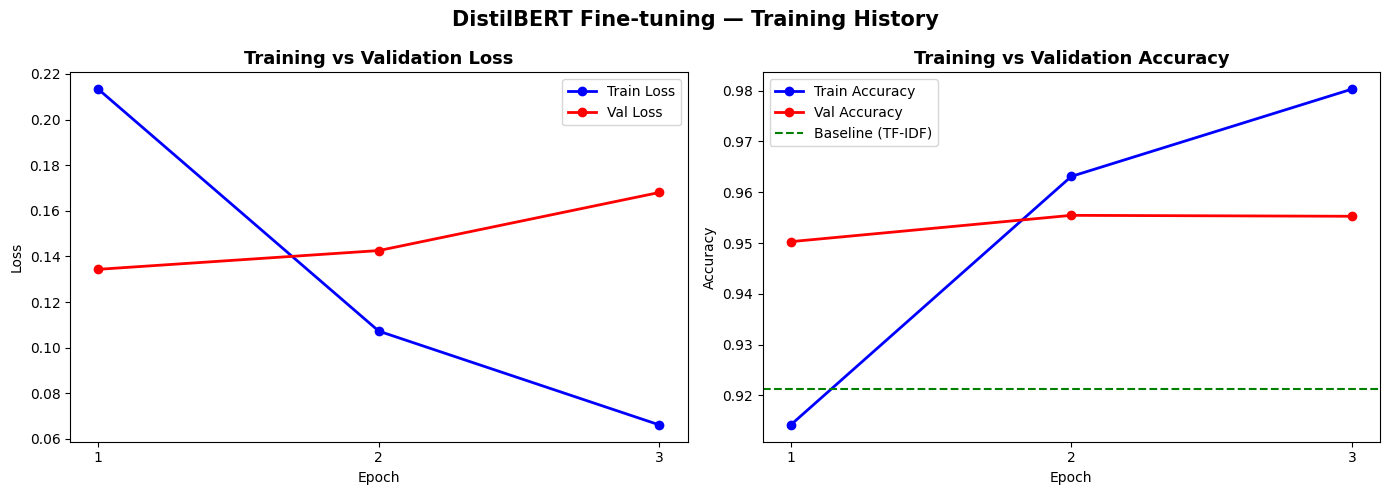

✅ Training curves saved

History:
  Epoch 1: train_acc=0.9142  val_acc=0.9503
  Epoch 2: train_acc=0.9631  val_acc=0.9555
  Epoch 3: train_acc=0.9803  val_acc=0.9553


In [9]:
# ============================================================
# TRAINING CURVES
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, CONFIG['epochs'] + 1)

# Loss curve
axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'],   'r-o', label='Val Loss',   linewidth=2)
axes[0].set_title('Training vs Validation Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].set_xticks(epochs_range)

# Accuracy curve
axes[1].plot(epochs_range, history['train_acc'], 'b-o', label='Train Accuracy', linewidth=2)
axes[1].plot(epochs_range, history['val_acc'],   'r-o', label='Val Accuracy',   linewidth=2)
axes[1].axhline(y=0.9212, color='green', linestyle='--', linewidth=1.5, label='Baseline (TF-IDF)')
axes[1].set_title('Training vs Validation Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].set_xticks(epochs_range)

plt.suptitle('DistilBERT Fine-tuning — Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['assets_path'], 'distilbert_training_curves.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ Training curves saved")
print("\nHistory:")
for ep in range(CONFIG['epochs']):
    print(f"  Epoch {ep+1}: train_acc={history['train_acc'][ep]:.4f}  val_acc={history['val_acc'][ep]:.4f}")